Вариант 1

In [28]:
import numpy as np
from scipy import stats

data = [63.2, 64.1, 62.8, 65.0, 63.9, 64.7, 62.5, 63.3, 64.0, 63.6, 
        62.9, 64.2, 63.1, 63.8, 64.5, 62.7, 63.4, 64.3, 63.0, 64.6]

data_array = np.array(data)

mu0 = 65  # эталонное значение (65%)
alpha = 0.05  # уровень значимости

n = len(data_array)  # количество наблюдений
mean = np.mean(data_array)  # среднее значение
std = np.std(data_array, ddof=1)  # стандартное отклонение (с поправкой)
se = std / np.sqrt(n)  # стандартная ошибка среднего

print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"Количество наблюдений: n = {n}")
print(f"Среднее значение: x̄ = {mean:.3f}%")
print(f"Стандартное отклонение: s = {std:.3f}%")
print(f"Стандартная ошибка: SE = {se:.3f}%")
print(f"Эталонное значение: μ₀ = {mu0}%")

t_statistic = (mean - mu0) / se
df = n - 1  # степени свободы

p_value = stats.t.cdf(t_statistic, df)

print("\n=== РЕЗУЛЬТАТЫ T-ТЕСТА ===")
print(f"t-статистика: t = {t_statistic:.4f}")
print(f"Степени свободы: df = {df}")
print(f"p-value: p = {p_value:.6f}")

print("\n=== ПРОВЕРКА ГИПОТЕЗЫ ===")
print(f"Уровень значимости: α = {alpha}")

if p_value < alpha:
    print("РЕЗУЛЬТАТ: Отвергаем нулевую гипотезу")
    print("ВЫВОД: Алгоритм сжимает данные ЛУЧШЕ эталонного (p < 0.05)")
else:
    print("РЕЗУЛЬТАТ: Не отвергаем нулевую гипотезу")
    print("ВЫВОД: Нет оснований считать, что алгоритм сжимает лучше эталонного")

conf_interval = stats.t.interval(0.95, df, loc=mean, scale=se)
print(f"\n95% доверительный интервал: ({conf_interval[0]:.3f}%, {conf_interval[1]:.3f}%)")

print(f"\nРазница с эталоном: {mean - mu0:.3f}%")
if mean < mu0:
    print("Наблюдаемое среднее НИЖЕ эталонного")
else:
    print("Наблюдаемое среднее ВЫШЕ эталонного")

=== ОСНОВНЫЕ СТАТИСТИКИ ===
Количество наблюдений: n = 20
Среднее значение: x̄ = 63.680%
Стандартное отклонение: s = 0.736%
Стандартная ошибка: SE = 0.165%
Эталонное значение: μ₀ = 65%

=== РЕЗУЛЬТАТЫ T-ТЕСТА ===
t-статистика: t = -8.0208
Степени свободы: df = 19
p-value: p = 0.000000

=== ПРОВЕРКА ГИПОТЕЗЫ ===
Уровень значимости: α = 0.05
РЕЗУЛЬТАТ: Отвергаем нулевую гипотезу
ВЫВОД: Алгоритм сжимает данные ЛУЧШЕ эталонного (p < 0.05)

95% доверительный интервал: (63.336%, 64.024%)

Разница с эталоном: -1.320%
Наблюдаемое среднее НИЖЕ эталонного


=== ОСНОВНЫЕ СТАТИСТИКИ ===
K-means (n=12):
  Среднее ARI: 0.7125
  Стандартное отклонение: 0.0242
DBSCAN (n=15):
  Среднее ARI: 0.6400
  Стандартное отклонение: 0.0267

=== ПРОВЕРКА НОРМАЛЬНОСТИ ===
K-means: p-value = 0.9512
DBSCAN: p-value = 0.7759
Тест Левена на равенство дисперсий: p-value = 0.7031

=== НЕЗАВИСИМЫЙ T-ТЕСТ ===
H₀: Среднее качество K-means = Среднее качество DBSCAN
H₁: Среднее качество K-means ≠ Среднее качество DBSCAN
t-статистика: 7.3031
p-value: 0.000000
РЕЗУЛЬТАТ: Отвергаем нулевую гипотезу
ВЫВОД: Есть статистически значимая разница в качестве

Разница средних: 0.0725 (K-means - DBSCAN)
K-means показывает ЗНАЧИТЕЛЬНО ЛУЧШЕЕ качество
95% доверительный интервал для разницы: (0.0523, 0.0927)


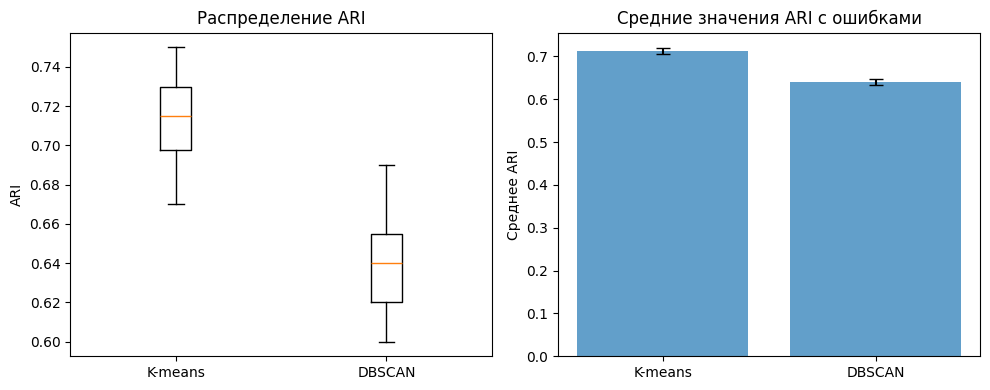


Размер эффекта (Коэн d): 2.8455
Очень большой размер эффекта


In [30]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

kmeans_ari = [0.72, 0.68, 0.75, 0.71, 0.73, 0.69, 0.74, 0.70, 0.72, 0.71, 0.73, 0.67]
dbscan_ari = [0.65, 0.63, 0.69, 0.61, 0.67, 0.64, 0.68, 0.62, 0.66, 0.60, 0.65, 0.63, 0.64, 0.62, 0.61]

kmeans = np.array(kmeans_ari)
dbscan = np.array(dbscan_ari)

alpha = 0.05

print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"K-means (n={len(kmeans)}):")
print(f"  Среднее ARI: {np.mean(kmeans):.4f}")
print(f"  Стандартное отклонение: {np.std(kmeans, ddof=1):.4f}")

print(f"DBSCAN (n={len(dbscan)}):")
print(f"  Среднее ARI: {np.mean(dbscan):.4f}")
print(f"  Стандартное отклонение: {np.std(dbscan, ddof=1):.4f}")

_, p_kmeans = stats.shapiro(kmeans)
_, p_dbscan = stats.shapiro(dbscan)

print(f"\n=== ПРОВЕРКА НОРМАЛЬНОСТИ ===")
print(f"K-means: p-value = {p_kmeans:.4f}")
print(f"DBSCAN: p-value = {p_dbscan:.4f}")

levene_stat, levene_p = stats.levene(kmeans, dbscan)
print(f"Тест Левена на равенство дисперсий: p-value = {levene_p:.4f}")

t_stat, p_value = stats.ttest_ind(kmeans, dbscan, equal_var=levene_p > 0.05)

print("\n=== НЕЗАВИСИМЫЙ T-ТЕСТ ===")
print("H₀: Среднее качество K-means = Среднее качество DBSCAN")
print("H₁: Среднее качество K-means ≠ Среднее качество DBSCAN")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < alpha:
    print("РЕЗУЛЬТАТ: Отвергаем нулевую гипотезу")
    print("ВЫВОД: Есть статистически значимая разница в качестве")
else:
    print("РЕЗУЛЬТАТ: Не отвергаем нулевую гипотезу")
    print("ВЫВОД: Нет статистически значимой разницы в качестве")

mean_diff = np.mean(kmeans) - np.mean(dbscan)
print(f"\nРазница средних: {mean_diff:.4f} (K-means - DBSCAN)")

if p_value < alpha:
    if mean_diff > 0:
        print("K-means показывает ЗНАЧИТЕЛЬНО ЛУЧШЕЕ качество")
    else:
        print("DBSCAN показывает ЗНАЧИТЕЛЬНО ЛУЧШЕЕ качество")

n1, n2 = len(kmeans), len(dbscan)
std1, std2 = np.std(kmeans, ddof=1), np.std(dbscan, ddof=1)
se_diff = np.sqrt(std1**2/n1 + std2**2/n2)
df = (std1**2/n1 + std2**2/n2)**2 / ((std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1))

t_critical = stats.t.ppf(0.975, df)
ci_low = mean_diff - t_critical * se_diff
ci_high = mean_diff + t_critical * se_diff

print(f"95% доверительный интервал для разницы: ({ci_low:.4f}, {ci_high:.4f})")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot([kmeans, dbscan], tick_labels=['K-means', 'DBSCAN'])
plt.title('Распределение ARI')
plt.ylabel('ARI')

plt.subplot(1, 2, 2)
plt.bar(['K-means', 'DBSCAN'], [np.mean(kmeans), np.mean(dbscan)], 
        yerr=[np.std(kmeans, ddof=1)/np.sqrt(len(kmeans)), np.std(dbscan, ddof=1)/np.sqrt(len(dbscan))], 
        capsize=5, alpha=0.7)
plt.title('Средние значения ARI с ошибками')
plt.ylabel('Среднее ARI')

plt.tight_layout()
plt.show()

effect_size = mean_diff / np.sqrt((std1**2 + std2**2)/2)
print(f"\nРазмер эффекта (Коэн d): {effect_size:.4f}")

if abs(effect_size) < 0.2:
    print("Маленький размер эффекта")
elif abs(effect_size) < 0.5:
    print("Средний размер эффекта")
elif abs(effect_size) < 0.8:
    print("Большой размер эффекта")
else:
    print("Очень большой размер эффекта")

=== ОСНОВНЫЕ СТАТИСТИКИ ===
L1-кэш (n=20):
  Средняя задержка: 45.55 мс
  Стандартное отклонение: 1.50 мс
L2-кэш (n=20):
  Средняя задержка: 53.55 мс
  Стандартное отклонение: 2.26 мс

Разности (L1 - L2):
  Средняя разность: -8.00 мс
  Стандартное отклонение разностей: 0.97 мс

=== ПРОВЕРКА НОРМАЛЬНОСТИ ===
L1-кэш: p-value = 0.2930
L2-кэш: p-value = 0.7557
Разности: p-value = 0.0027

=== ПАРНЫЙ T-ТЕСТ ===
H₀: Средняя задержка L1 = Средняя задержка L2
H₁: Средняя задержка L1 ≠ Средняя задержка L2
t-статистика: -36.7575
p-value: 0.000000
РЕЗУЛЬТАТ: Отвергаем нулевую гипотезу
ВЫВОД: Есть статистически значимая разница между типами кэширования

Средняя разница: -8.00 мс (L1 - L2)
L1-кэш работает ЗНАЧИТЕЛЬНО БЫСТРЕЕ L2-кэша
95% доверительный интервал для разницы: (-8.46, -7.54) мс


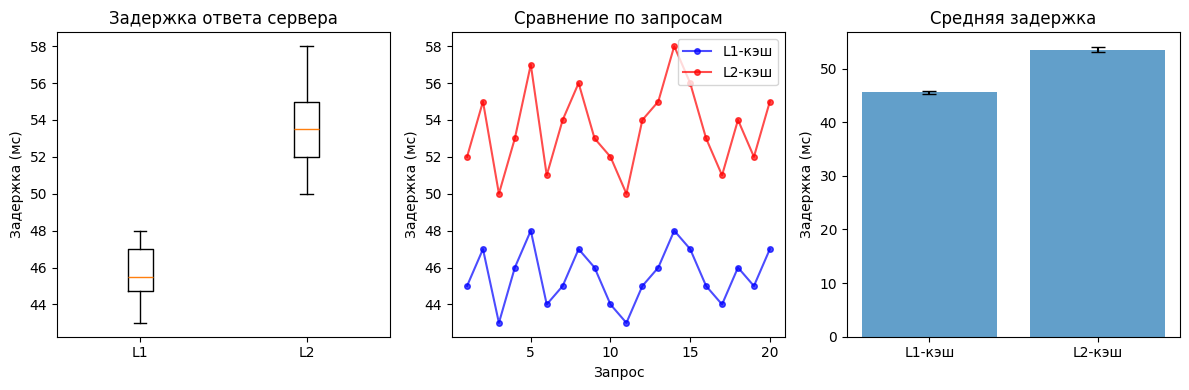


Размер эффекта (Коэн d): 8.2192
Очень большой размер эффекта
L1-кэш быстрее L2-кэша на 14.9%


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

l1_latency = [45, 47, 43, 46, 48, 44, 45, 47, 46, 44, 43, 45, 46, 48, 47, 45, 44, 46, 45, 47]
l2_latency = [52, 55, 50, 53, 57, 51, 54, 56, 53, 52, 50, 54, 55, 58, 56, 53, 51, 54, 52, 55]

l1 = np.array(l1_latency)
l2 = np.array(l2_latency)

alpha = 0.05

print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"L1-кэш (n={len(l1)}):")
print(f"  Средняя задержка: {np.mean(l1):.2f} мс")
print(f"  Стандартное отклонение: {np.std(l1, ddof=1):.2f} мс")

print(f"L2-кэш (n={len(l2)}):")
print(f"  Средняя задержка: {np.mean(l2):.2f} мс")
print(f"  Стандартное отклонение: {np.std(l2, ddof=1):.2f} мс")

diff = l1 - l2
print(f"\nРазности (L1 - L2):")
print(f"  Средняя разность: {np.mean(diff):.2f} мс")
print(f"  Стандартное отклонение разностей: {np.std(diff, ddof=1):.2f} мс")

_, p_l1 = stats.shapiro(l1)
_, p_l2 = stats.shapiro(l2)
_, p_diff = stats.shapiro(diff)

print(f"\n=== ПРОВЕРКА НОРМАЛЬНОСТИ ===")
print(f"L1-кэш: p-value = {p_l1:.4f}")
print(f"L2-кэш: p-value = {p_l2:.4f}")
print(f"Разности: p-value = {p_diff:.4f}")

t_stat, p_value = stats.ttest_rel(l1, l2)

print("\n=== ПАРНЫЙ T-ТЕСТ ===")
print("H₀: Средняя задержка L1 = Средняя задержка L2")
print("H₁: Средняя задержка L1 ≠ Средняя задержка L2")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < alpha:
    print("РЕЗУЛЬТАТ: Отвергаем нулевую гипотезу")
    print("ВЫВОД: Есть статистически значимая разница между типами кэширования")
else:
    print("РЕЗУЛЬТАТ: Не отвергаем нулевую гипотезу")
    print("ВЫВОД: Нет статистически значимой разницы между типами кэширования")

mean_diff = np.mean(diff)
print(f"\nСредняя разница: {mean_diff:.2f} мс (L1 - L2)")

if p_value < alpha:
    if mean_diff < 0:
        print("L1-кэш работает ЗНАЧИТЕЛЬНО БЫСТРЕЕ L2-кэша")
    else:
        print("L2-кэш работает ЗНАЧИТЕЛЬНО БЫСТРЕЕ L1-кэша")

se_diff = np.std(diff, ddof=1) / np.sqrt(len(diff))
df = len(diff) - 1
t_critical = stats.t.ppf(0.975, df)
ci_low = mean_diff - t_critical * se_diff
ci_high = mean_diff + t_critical * se_diff

print(f"95% доверительный интервал для разницы: ({ci_low:.2f}, {ci_high:.2f}) мс")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.boxplot([l1, l2], tick_labels=['L1', 'L2'])
plt.title('Задержка ответа сервера')
plt.ylabel('Задержка (мс)')

plt.subplot(1, 3, 2)
x = range(1, len(l1) + 1)
plt.plot(x, l1, 'bo-', label='L1-кэш', alpha=0.7, markersize=4)
plt.plot(x, l2, 'ro-', label='L2-кэш', alpha=0.7, markersize=4)
plt.xlabel('Запрос')
plt.ylabel('Задержка (мс)')
plt.title('Сравнение по запросам')
plt.legend()

plt.subplot(1, 3, 3)
plt.bar(['L1-кэш', 'L2-кэш'], [np.mean(l1), np.mean(l2)], 
        yerr=[np.std(l1, ddof=1)/np.sqrt(len(l1)), np.std(l2, ddof=1)/np.sqrt(len(l2))], 
        capsize=5, alpha=0.7)
plt.title('Средняя задержка')
plt.ylabel('Задержка (мс)')

plt.tight_layout()
plt.show()

effect_size = abs(mean_diff) / np.std(diff, ddof=1)
print(f"\nРазмер эффекта (Коэн d): {effect_size:.4f}")

if effect_size < 0.2:
    print("Маленький размер эффекта")
elif effect_size < 0.5:
    print("Средний размер эффекта")
elif effect_size < 0.8:
    print("Большой размер эффекта")
else:
    print("Очень большой размер эффекта")

faster_percent = (abs(mean_diff) / np.mean(l2)) * 100
print(f"L1-кэш быстрее L2-кэша на {faster_percent:.1f}%")